#📌 Extracción

In [1]:
#importamos librerías
import pandas as pd
import json


In [2]:
#cargamos el archivo json y lo ponemos en una variable
with open("TelecomX_Data.json") as f:
    datos = json.load(f)

#🔧 Transformación

In [4]:
#como vienen lso datos anidados, normalizamos
df = pd.json_normalize(datos)


##Explorando los datos

In [5]:
#ver forma
df.shape

(7267, 21)

In [6]:
#ver un poco del df
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
#ver información más detallada
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [8]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


Columnas relevantes para análisis de evasión:
Churn es la variable objetivo porque indica si el cliente abandonó la empresa o no.
Se consideraron como variables importantes: tenure, Contract, PaymentMethod, InternetService, PhoneService y los cargos mensuales y totales, ya que pueden estar relacionados con la evasión de clientes.

##Limpieza de datos


###Ver si hay nombres raros de las columnas

In [16]:
#ver inconsistencias en las categorías
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


###Estandarizar nombres

In [17]:
#cambiamos puntos por guiones bajos y que todo quede en minúsculas
df.columns = df.columns.str.lower().str.replace('.', '_').str.replace(' ', '_')

In [19]:
#nombres estandarizados
df.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [25]:
#cambiamos solo el nombre de una columnas más
df = df.rename(columns={"customerid": "customer_id"})
df.columns

Index(['customer_id', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

Buscar y corregir errores

In [26]:
#ver posibles errores en las categorías
df["churn"].unique()
df["customer_gender"].unique()
df["internet_internetservice"].unique()
df["account_contract"].unique()
df["account_paymentmethod"].unique()


array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

###Verificación y eliminació de datos faltantes o vacíos

In [28]:
#ver si hay datos faltantes
df.isnull().sum()



,0
customer_id,0
churn,224
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0


Valores vacíos

In [29]:
#vemos si hay valores vacíos
(df == "").sum()

,0
customer_id,0
churn,0
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0


In [31]:
#encontramos valores vacíos en Churn, entonces los indicamos co NA:
df["churn"].replace("", pd.NA, inplace=True)
#y verificamos nuevamente
df["churn"].isnull().sum()
#ya identificamos 224 valores faltantes

/tmp/ipykernel_551/2351167545.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["churn"].replace("", pd.NA, inplace=True)


np.int64(224)

In [32]:
#corrección de valores churn faltantes
#churn es la variable objetivo entonces eliminamos las filas de datos faltantes
df = df.dropna(subset=["churn"])
df.isnull().sum()


,0
customer_id,0
churn,0
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0



###Verificación y cambio de tipos de datos

In [13]:
#tipos de datos
print("\nTipos de datos")
print(df.dtypes)


Tipos de datos
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object


In [33]:
#account.Charges.Total debería ser numérico entonces corregimos:
df["account_charges_total"] = pd.to_numeric(df["account_charges_total"], errors="coerce")

/tmp/ipykernel_551/4282998473.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["account_charges_total"] = pd.to_numeric(df["account_charges_total"], errors="coerce")


In [34]:
#verificamos que no queden datos nulos
df.isnull().sum()

,0
customer_id,0
churn,0
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0


In [36]:
#algunos datos no se pudieron hacer numéricos y son na
#los eliminamos y verificamos
df = df.dropna(subset=["account_charges_total"])
df.isnull().sum()


,0
customer_id,0
churn,0
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0


In [38]:
#datos después de la limpieza
df.shape

(7032, 21)

###Crear nueva columna cuentas_diarias.

Utilizar la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [39]:
#facturación mensual está en account_charges_monthly entonces:
df["cuentas_diarias"] = df["account_charges_monthly"] / 30

In [41]:
df[["account_charges_monthly", "cuentas_diarias"]].head()

,account_charges_monthly,cuentas_diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [43]:
#verificamos que sea decimal y si
df["cuentas_diarias"].dtype

dtype('float64')

###Conversión de texto (Yes/No) a valores binarios (0/1)

In [44]:
df.head()
#en algunas columnas hay si o no
#esto conviene convertirlo a valores binarios para un mejor análisis después

,customer_id,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [45]:
#convertimos los valores de churn a binarios 1/0
#Yes → 1 No → 0
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})

In [46]:
#verificamos que funcionó
df["churn"].unique()

array([0, 1])

In [47]:
#convertimos otras columnas con Yes y No que convienen:
binary_columns = [
    "customer_partner",
    "customer_dependents",
    "phone_phoneservice",
    "account_paperlessbilling"
]

for col in binary_columns:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [49]:
#Hay columnas donde no conviene hacer esto todavía, por ejemplo: internet_internetservice account_contract account_paymentmethod
#porque tienen más de dos categorías.
df.head()

,customer_id,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

##Análisis descriptivo

In [50]:
df.describe()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [51]:
#transpocisión de tabla para ver mejor los datos
df.describe().T

,count,mean,std,min,25%,50%,75%,max
churn,7032.0,0.265785,0.441782,0.000000,0.00000,0.000,1.000000,1.000000
customer_seniorcitizen,7032.0,0.162400,0.368844,0.000000,0.00000,0.000,0.000000,1.000000
customer_partner,7032.0,0.482509,0.499729,0.000000,0.00000,0.000,1.000000,1.000000
customer_dependents,7032.0,0.298493,0.457629,0.000000,0.00000,0.000,1.000000,1.000000
customer_tenure,7032.0,32.421786,24.545260,1.000000,9.00000,29.000,55.000000,72.000000
phone_phoneservice,7032.0,0.903299,0.295571,0.000000,1.00000,1.000,1.000000,1.000000
account_paperlessbilling,7032.0,0.592719,0.491363,0.000000,0.00000,1.000,1.000000,1.000000
account_charges_monthly,7032.0,64.798208,30.085974,18.250000,35.58750,70.350,89.862500,118.750000
account_charges_total,7032.0,2283.300441,2266.771362,18.800000,401.45000,1397.475,3794.737500,8684.800000
cuentas_diarias,7032.0,2.159940,1.002866,0.608333,1.18625,2.345,2.995417,3.958333


##Distribución de Churn.
Vemos cuantos clientes en cada categoría

In [52]:
#1 = cliente que se fue/0 = cliente que permaneció
df["churn"].value_counts()

,count
churn,
0,5163
1,1869


In [53]:
#para verlo mejor en porcentajes
df["churn"].value_counts(normalize=True)


,proportion
churn,
0,0.734215
1,0.265785


73% permanecen
27% abandonan

##Gráfico de distribución

In [54]:
#importamos librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

Cuántos clientes hay en cada grupo

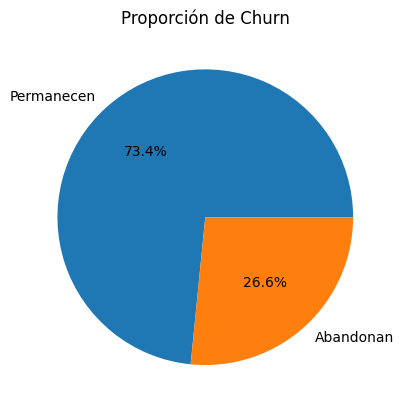

In [56]:
df["churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Permanecen", "Abandonan"]
)

plt.title("Proporción de Churn")
plt.ylabel("")

plt.show()

Tasa de abandono de clientes

In [57]:
#si abandono es 1 entonces
df["churn"].mean()

np.float64(0.26578498293515357)

Tasa de abandono del 27%

Este análisis permite dimensionar la magnitud del problema de evasión y sirve como punto de partida para investigar qué factores podrían estar influyendo en el abandono de clientes.

##Comparación de churn con variables categóricas

¿Los clientes con cierto contrato cancelan más?

¿El método de pago influye?

¿El género tiene alguna relación?

hacemos gráficos de comparación

Churn según género

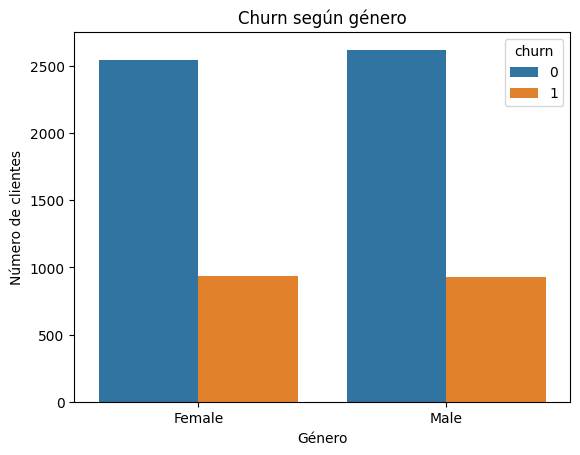

In [58]:
#no vemos diferencia por género en el abandono
sns.countplot(x="customer_gender", hue="churn", data=df)

plt.title("Churn según género")
plt.xlabel("Género")
plt.ylabel("Número de clientes")

plt.show()

Proporción por género

In [64]:
pd.crosstab(df["customer_gender"], df["churn"], normalize="index")

churn,0,1
customer_gender,,
Female,0.730405,0.269595
Male,0.737954,0.262046


Churn según tipo de contrato


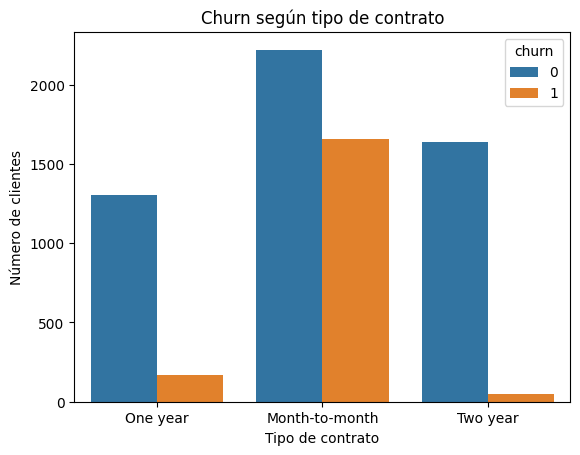

In [59]:
#mayor abandono en el contrato de mes a mes en comparación con los otros tipos
sns.countplot(x="account_contract", hue="churn", data=df)

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Número de clientes")

plt.show()

Proporción por contrato

In [62]:

pd.crosstab(df["account_contract"], df["churn"], normalize="index")

churn,0,1
account_contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


Churn según método de pago


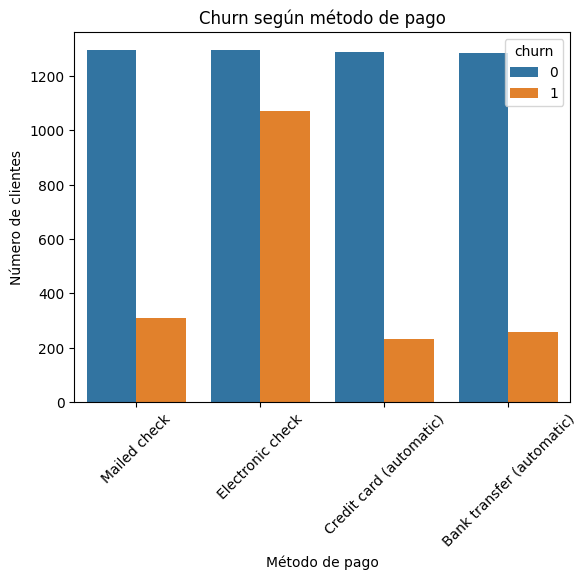

In [60]:
#más abandono por electronic check
sns.countplot(x="account_paymentmethod", hue="churn", data=df)

plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de clientes")

plt.xticks(rotation=45)

plt.show()

Proporción por método de pago

In [63]:
pd.crosstab(df["account_paymentmethod"], df["churn"], normalize="index")

churn,0,1
account_paymentmethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


Churn según servicio de internet

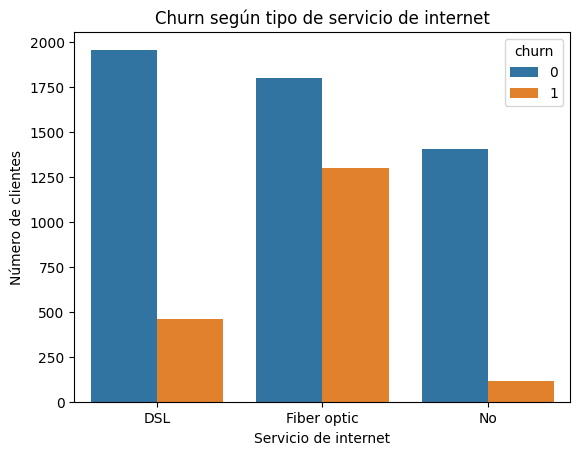

In [61]:
#más abandono cuando se tiene fibra óptica
sns.countplot(x="internet_internetservice", hue="churn", data=df)

plt.title("Churn según tipo de servicio de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Número de clientes")

plt.show()

Propoción por servicio de internet


In [65]:
pd.crosstab(df["internet_internetservice"], df["churn"], normalize="index")

churn,0,1
internet_internetservice,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


##Comparación de churn con variables numéricas

Análisis estadístico de variables numéricas

In [70]:
df.groupby("churn")[[
    "customer_tenure",
    "account_charges_monthly",
    "account_charges_total",
    "cuentas_diarias"
]].describe()

customer_tenure                                                     \
                count       mean        std  min   25%   50%   75%   max   
churn                                                                      
0              5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0   
1              1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      account_charges_monthly             ... account_charges_total           \
                        count       mean  ...                   75%      max   
churn                                     ...                                  
0                      5163.0  61.307408  ...              4264.125  8672.45   
1                      1869.0  74.441332  ...              2331.300  8684.80   

      cuentas_diarias                                                    \
                count      mean       std       min       25%       50%   
churn                                                                     
0              5163.0  2.043580  1.036485  0.608333  0.836667  2.148333   
1              1869.0  2.481378  0.822202  0.628333  1.871667  2.655000   

                           
            75%       max  
churn                      
0      2.949167  3.958333  
1      3.140000  3.945000  

[2 rows x 32 columns]

In [71]:
#mejora de tabla
df.groupby("churn")[[
    "customer_tenure",
    "account_charges_monthly",
    "account_charges_total",
    "cuentas_diarias"
]].mean().round(2)

,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias
churn,,,,
0,37.65,61.31,2555.34,2.04
1,17.98,74.44,1531.80,2.48


Análisis con gráficos

Churn vs tiempo como cliente (tenure).
Esto muestra si los clientes que cancelan llevan menos tiempo en la empresa.





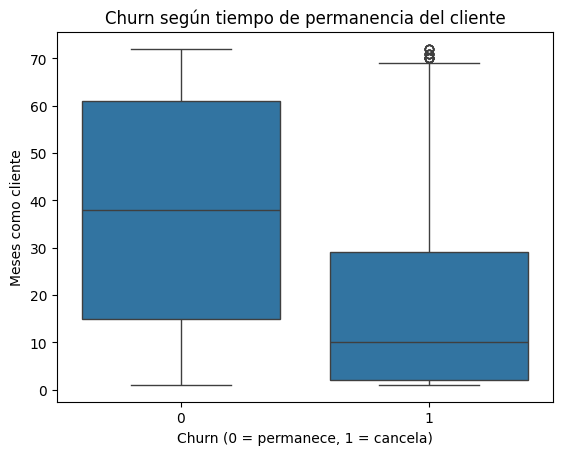

In [72]:
sns.boxplot(x="churn", y="customer_tenure", data=df)

plt.title("Churn según tiempo de permanencia del cliente")
plt.xlabel("Churn (0 = permanece, 1 = cancela)")
plt.ylabel("Meses como cliente")

plt.show()

Churn vs cargos mensuales.
Esto ayuda a ver si los clientes que pagan más tienden a cancelar.


Text(0, 0.5, 'Cargo mensual')

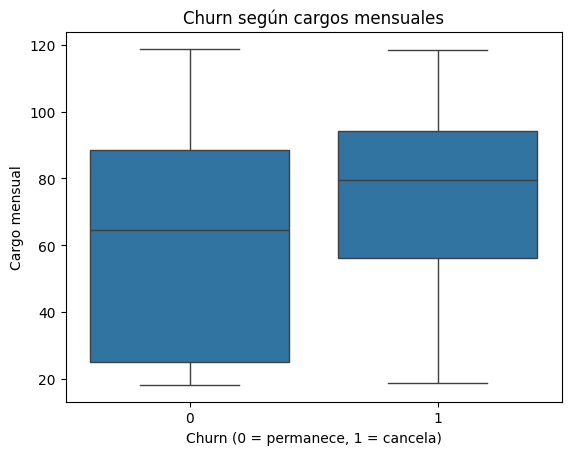

In [67]:
sns.boxplot(x="churn", y="account_charges_monthly", data=df)

plt.title("Churn según cargos mensuales")
plt.xlabel("Churn (0 = permanece, 1 = cancela)")
plt.ylabel("Cargo mensual")


Churn vs gasto total.


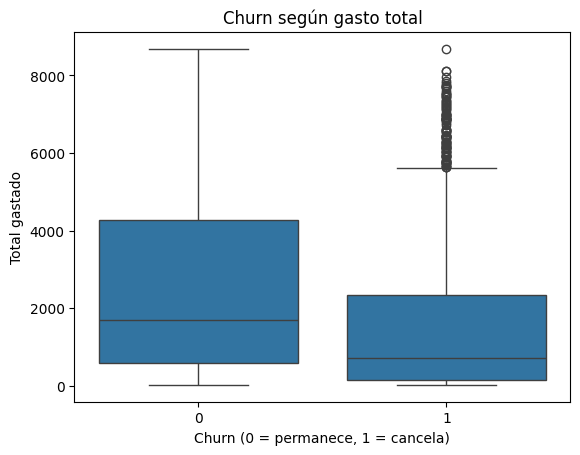

In [68]:
sns.boxplot(x="churn", y="account_charges_total", data=df)

plt.title("Churn según gasto total")
plt.xlabel("Churn (0 = permanece, 1 = cancela)")
plt.ylabel("Total gastado")

plt.show()

Churn vs cuentas diarias.
Esto ayuda a comparar el costo real del servicio por día.

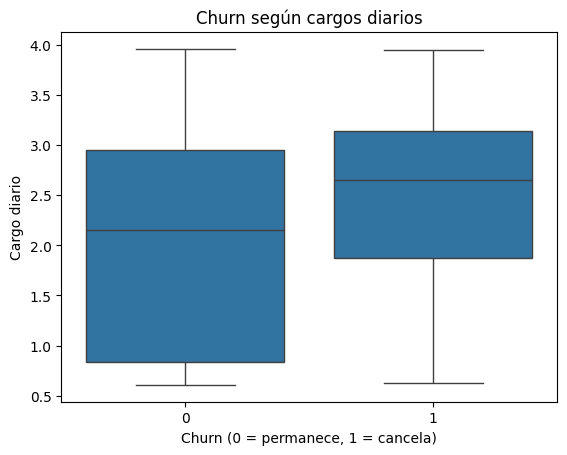

In [69]:
sns.boxplot(x="churn", y="cuentas_diarias", data=df)

plt.title("Churn según cargos diarios")
plt.xlabel("Churn (0 = permanece, 1 = cancela)")
plt.ylabel("Cargo diario")

plt.show()

##Extra: Análisis de correlación general

In [73]:
#Análisis general entre variables
df[[
    "churn",
    "customer_tenure",
    "account_charges_monthly",
    "account_charges_total",
    "cuentas_diarias"
]].corr()

,churn,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias
churn,1.000000,-0.354049,0.192858,-0.199484,0.192858
customer_tenure,-0.354049,1.000000,0.246862,0.825880,0.246862
account_charges_monthly,0.192858,0.246862,1.000000,0.651065,1.000000
account_charges_total,-0.199484,0.825880,0.651065,1.000000,0.651065
cuentas_diarias,0.192858,0.246862,1.000000,0.651065,1.000000


##Extra: Análisis de correlación específica entre algunas variables

Variables que tienen relación

In [75]:
variables_clave = [
    "churn",
    "customer_tenure",
    "account_charges_monthly",
    "account_charges_total",
    "cuentas_diarias"
]

df[variables_clave].corr().round(3)

,churn,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias
churn,1.000,-0.354,0.193,-0.199,0.193
customer_tenure,-0.354,1.000,0.247,0.826,0.247
account_charges_monthly,0.193,0.247,1.000,0.651,1.000
account_charges_total,-0.199,0.826,0.651,1.000,0.651
cuentas_diarias,0.193,0.247,1.000,0.651,1.000


Heatmap

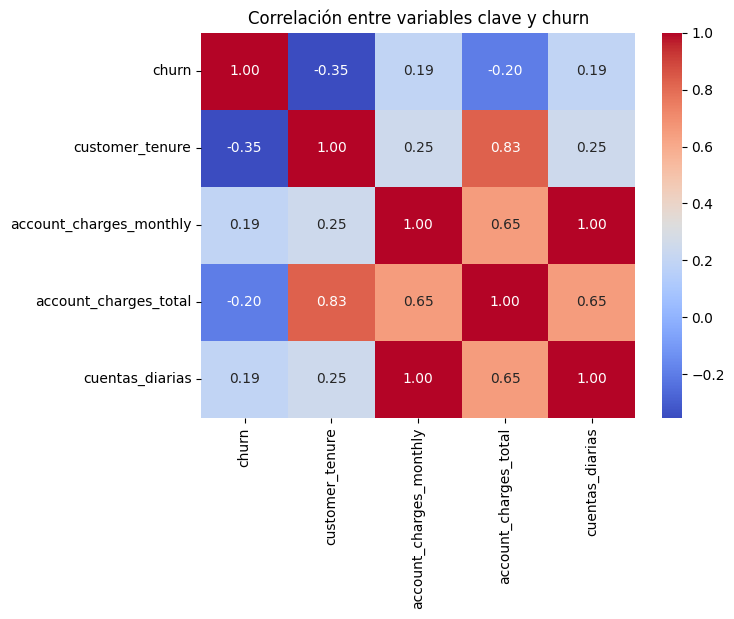

In [76]:
corr = df[variables_clave].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlación entre variables clave y churn")

plt.show()

In [78]:
df[variables_clave].corr()["churn"].sort_values()

,churn
customer_tenure,-0.354049
account_charges_total,-0.199484
account_charges_monthly,0.192858
cuentas_diarias,0.192858
churn,1.000000


Resumen de correlación: El análisis de correlación muestra que la variable numérica más relacionada con la evasión de clientes es customer_tenure, con una correlación negativa moderada (-0.354). Esto indica que los clientes con menor tiempo de permanencia presentan mayor probabilidad de cancelar el servicio. Por otro lado, variables como account_charges_monthly y cuentas_diarias presentan una correlación positiva débil con churn, lo que sugiere que cargos más altos podrían estar asociados con una mayor probabilidad de cancelación. Finalmente, account_charges_total muestra una correlación negativa débil, reflejando que los clientes que permanecen más tiempo tienden a acumular mayor gasto total.

#📄Informe final

##Introducción

La evasión de clientes, conocida como churn, puede llegar a ser un gran desafío para las empresas. La pérdida de clientess puede representar una afectación significativa en los ingreos y, por lo tanto, en la estabilidad del negocio. Investigar qué factores específicos contribuyen a que los clientes se retiren de la empresa, permite entonces que se desarrollen estrategias para mejorar la retención de clientes.

El objetivo de este análisis es explorar los datos de clientes de Telecom X para identificar patrones asociados con la evasión. A través de técnicas de limpieza de datos, análisis exploratorio y visualización, se busca comprender qué características de los clientes están relacionadas con una mayor probabilidad de cancelación de los servicios.


##Limpieza y Tratamiento de Datos

Se importaron y se prepararon los datos con el fin de verificar su consistencia para un análisis adecuado.

Se realizó lo siguiente:

-Se cargaron los datos en formato JSON y se transformaron en un DataFrame de Pandas para facilitar su manipulación.

-Se exploró la estructura del dataset y se revisaron los tipos de datos de cada variable.

-Se estandarizaron los nombres de las columnas, convirtiéndolos a minúsculas y reemplazando caracteres especiales por guiones bajos para facilitar su uso en el análisis.

-Se identificaron valores faltantes y registros con valores vacíos en la variable churn, los cuales fueron eliminados debido a que esta variable representa el objetivo del análisis.

-Se corrigieron los tipos de datos de algunas variables numéricas, como account_charges_total, que originalmente estaba almacenada como texto.

-Se eliminaron registros con valores nulos en variables críticas.

-Se creó una nueva variable llamada cuentas_diarias, calculada a partir de los cargos mensuales, para obtener una medida más detallada del costo diario del servicio.

Estas acciones permitieron obtener un dataset limpio, consistente y listo para el análisis exploratorio.

##Análisis Exploratorio de Datos

###Análisis de distribución de la evasión.

####Porporción de evasión

Primero se analizó la distribución de la variable churn, observando la proporción de clientes que permanecen en la empresa frente a aquellos que cancelan el servicio. Este análisis se realizó numéricamente y ggráficamente para poder visualizar mejor los compartamientos de churn por categoría.
Se tuvo los siguiente:


Se observa que el 27% de los clientes abandonan la empresa, mientras que el 73 se queda.
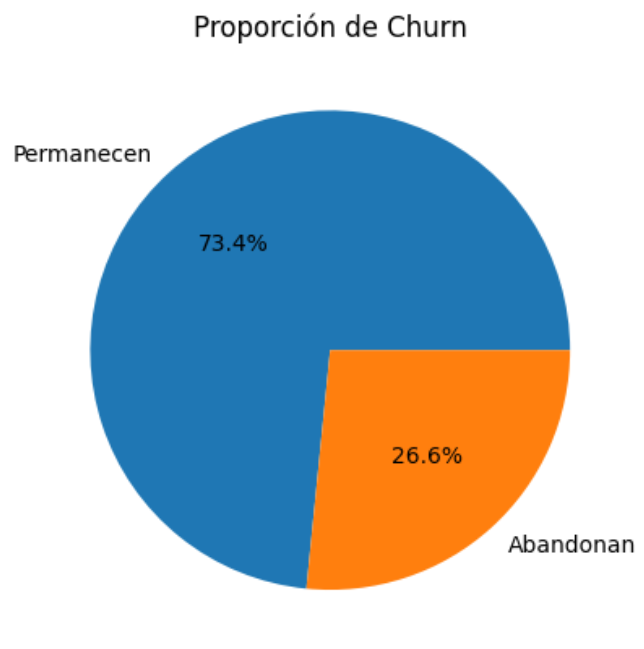

###Relación entre la evasión y diferentes variables categóricas

Se exploró la relación entre la evasión y diferentes variables categóricas, incluyendo:

-género del cliente

-tipo de contrato

-método de pago

-tipo de servicio de internet

Se obtuvo lo siguiente para cada categoría:

####Churn y género del cliente.

No parece haber relación entre la evasión y el género del cliente.
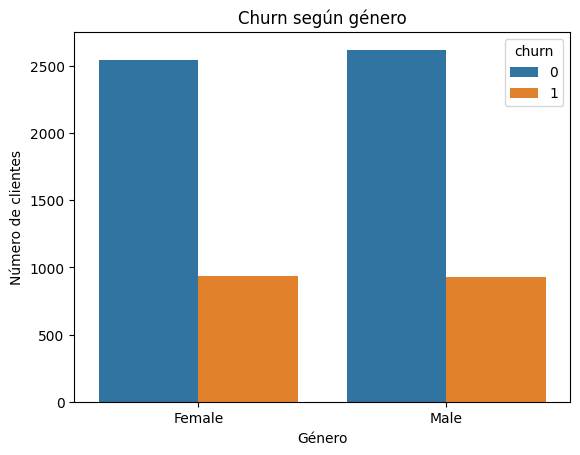

####Churn y tipo de contrato.

Los clientes abandonan el servicio en mayor medida en el contrato que es mes con mes.

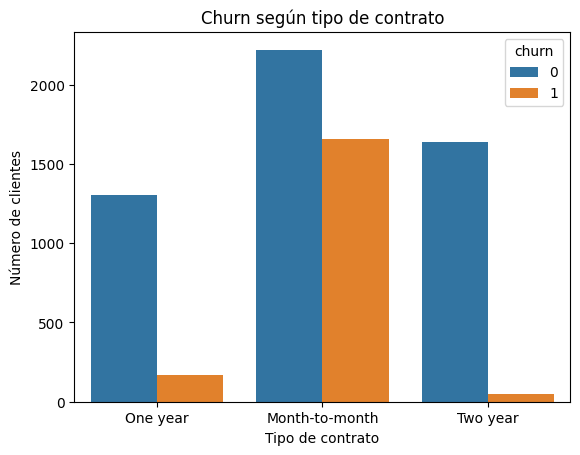


####Churn y método de pago.

Los clientes que pagan con cheque electrónico presentan una mayor evasión.

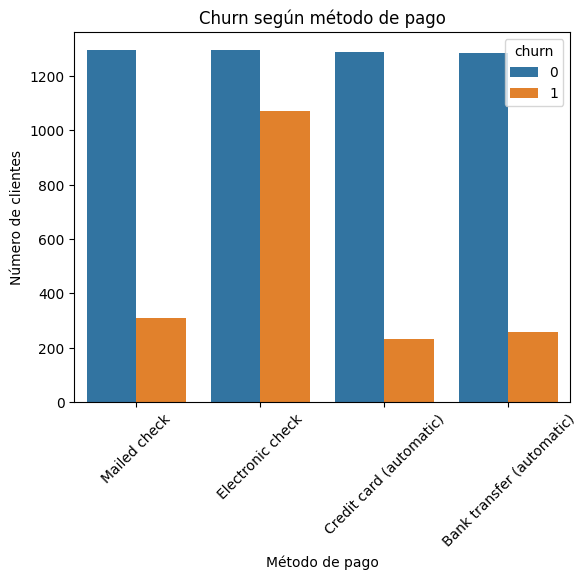

####Churn y servicio de internet.

Clientes con el servicio de internet de fibra óptica presentan una mayor evasión.

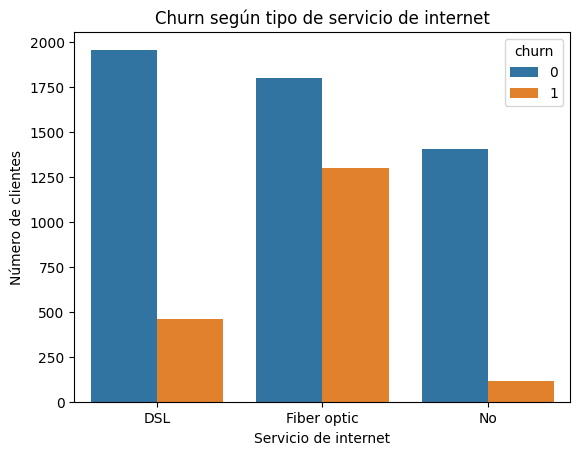

####Resultados para variables categóticas

Los resultados mostraron patrones claros en algunas variables. En particular, los clientes con contratos de mes a mes presentan una tasa significativamente mayor de cancelación en comparación con aquellos con contratos de uno o dos años. De igual manera, los clientes que utilizan el cheque electrónico como método de pago presentan mayores niveles de evasión.

###Relación entre la evasión y variables númericas.

Se exploró la relación entre la evasión y diferentes variables numéricas, incluyendo:

-tiempo de permanencia del cliente (tenure)

-cargos mensuales

-gasto total acumulado

-cargos diarios estimados

Se obtuvo lo siguiente para cada categoría:

####Churn y tiempo de permanencia del cliente.

-Los clientes que permanecen (0) tienen una mediana alrededor de 35–40 meses.

-Los clientes que cancelan (1) tienen una mediana cercana a 10 meses.

-La mayoría de los clientes que cancelan tienen poco tiempo en la empresa.

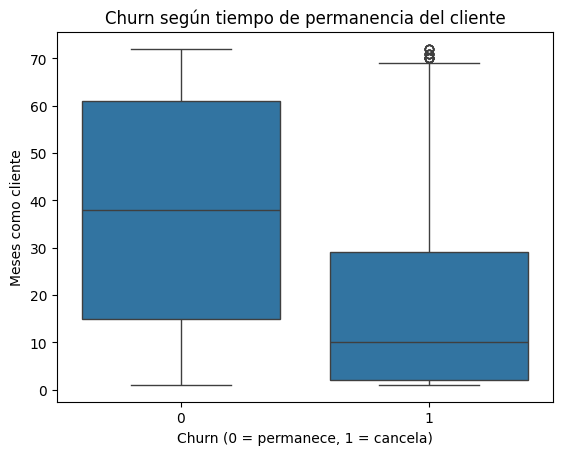

####Churn y cargos mensuales.
Clientes que pagan más mes con mes, tienden a cancelar.

-Los clientes que cancelan tienen cargos mensuales más altos en promedio.

-La mediana de churn = 1 es mayor que la de churn = 0.

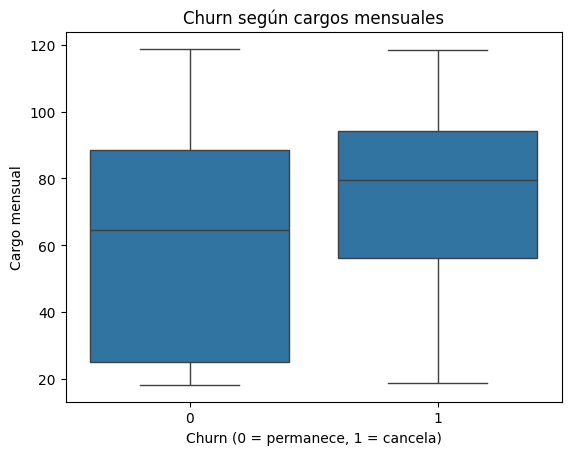



####Churn y gasto total acumulado.
Clientes que han gastado más en total tienden a quedarse.

-Los clientes que permanecen han gastado mucho más en total.

-Los clientes que cancelan tienen valores mucho más bajos.

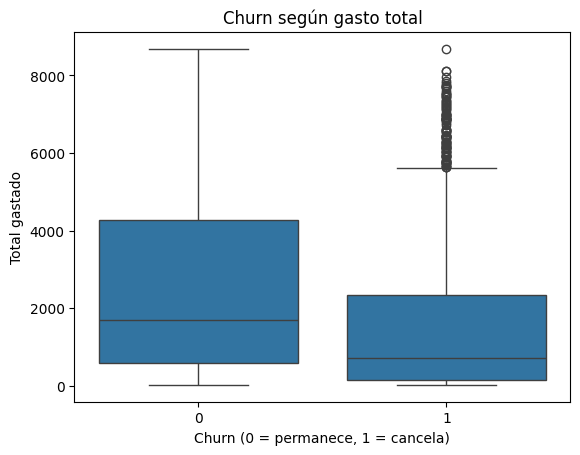

####Churn y cargos diarios estimados.

-Los clientes que cancelan presentan ligeramente mayores cargos diarios.

-La mediana de churn = 1 es mayor.

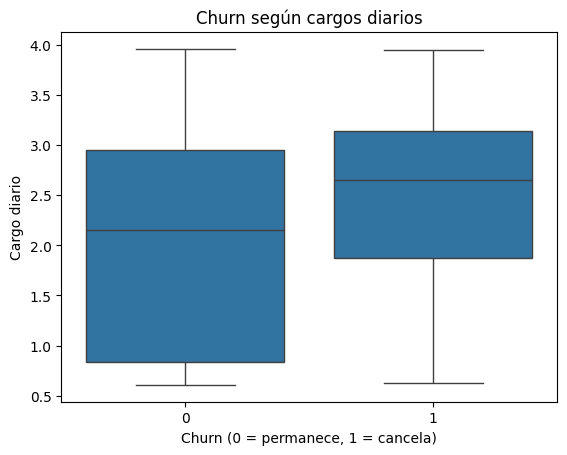


####Resultados de para variables numéricas.

El análisis de variables numéricas revela patrones importantes asociados con la evasión de clientes. En particular, **los clientes que cancelan el servicio suelen tener menor tiempo de permanencia en la empresa y presentan cargos mensuales y diarios ligeramente más altos**. Asimismo, **el gasto total acumulado es mayor en los clientes que permanecen, lo cual está relacionado con su mayor antigüedad**. Estos resultados sugieren que tanto el tiempo de relación con el cliente como los costos del servicio pueden influir en la probabilidad de cancelación.

###Análisis de correlación

####Heatmap

Para identificar posibles relaciones entre las variables numéricas y la evasión de clientes, se calculó una matriz de correlación. Con el fin de visualizar mejor estas correlaciones si hizo un Heat map.

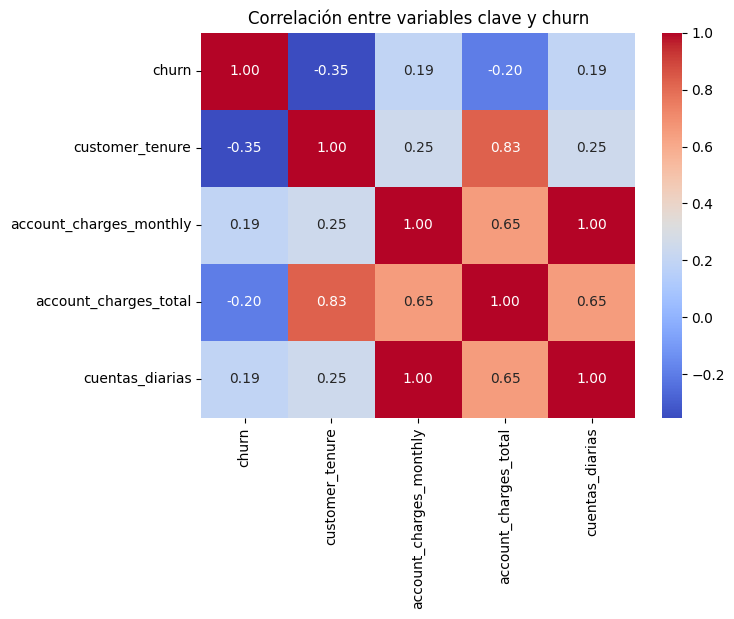

####Resultados de análisis de correlación

-tenure y Churn fue la relación má fuerte que incluye a la evasión(-0.354). A mayor tiempo de permanencia del cliente, menor probabilidad de cancelación.

-account_charges_monthly y churn (0.193). Correlación positiva débil que los clientes con cargos mensuales más altos tienden ligeramente más a cancelar.

-account_charges_total y churn (0.199). s una correlación negativa débil.Los clientes que han gastado más en total tienden menos a cancelar.

-cuentas_diarias y churn (0.193). Igual a account_charges_monthly, porque cuentas_diarias fueron calculadas directamente a partir de esa variable.

-customer_tenure y account_charges_total (0.826).Correlación positiva fuerte. Mientras más tiempo lleva un cliente en la empresa,
mayor es su gasto total acumulado.



Se observó que los clientes que cancelan el servicio suelen tener menor antigüedad en la empresa y cargos mensuales ligeramente más altos.

##Conclusiones e Insights

Los análisis realizados permitieron indetificar algunos factores asociados con la evasión de clientes en la empresa Telecom X.

Uno de los factores más importantes es el tiempo de permanencia del cliente. Los clientes con menor antigüedad presentan mayor probabilidad de cancelar el servicio, lo que sugiere que los primeros meses de relación con el cliente son especialmente críticos.

Otro factor relevante es el tipo de contrato. Los contratos mensuales muestran tasas de evasión significativamente mayores que los contratos a largo plazo, lo que sugiere que los compromisos de mayor duración favorecen que los clientes se queden.

También se identificaron patrones relacionados con el método de pago, donde los clientes que utilizan cheques electrónicos presentan mayores niveles de cancelación de los servicios.

En cuanto a las variables de costo, se observó que los clientes que presentan mayor evasión tienden a tener cargos mensuales ligeramente más altos, lo que podría indicar que el precio del servicio influye en la decisión de abandonar la empresa.

En conjunto, estos resultados muestran que la evasión de clientes está asociada a una combinación de factores relacionados con el tiempo de permanencia, el tipo de contrato y las características del servicio contratado.

##Recomendaciones


Con base en los resultados del análisis, se proponen las siguientes recomendaciones para reducir la evasión de clientes en la empresa Telecom X:

1. Fortalecer estrategias de retención para nuevos clientes.
Dado que los clientes con menor antigüedad presentan mayor probabilidad de cancelar el servicio, se recomienda implementar programas destinados a promover que los clientes se queden durante los primeros meses, como promociones, descuentos o seguimiento personalizado.

2. Incentivar contratos a largo plazo.
Los contratos de uno o dos años presentan menor evasión. Ofrecer beneficios adicionales o descuentos para clientes que opten por contratos más largos podría mejorar la retención.

3. Revisar la experiencia del cliente en planes de mayor costo.
Dado que los cargos mensuales más altos están asociados con mayor evasión, podría ser útil evaluar la percepción de valor de estos planes y mejorar los servicios ofrecidos.

4. Promover métodos de pago automáticos
Los clientes que utilizan cheques electrónicos muestran mayor tendencia a cancelar el servicio. Incentivar métodos de pago automáticos como tarjeta de crédito o transferencia bancaria podría contribuir a reducir la evasión.

5. Analizar en mayor profundidad los servicios de internet de alta velocidad.
Dado que algunos tipos de servicio, como fibra óptica, presentan mayores tasas de cancelación, sería recomendable investigar posibles problemas relacionados con calidad del servicio o expectativas del cliente.